<a href="https://colab.research.google.com/github/Jpablo179804/MineriaDatos/blob/main/Final/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Minería de Datos: Reconocimiento de Voz "Luz Inteligente"

##Fase 1

### DATOS:
1. Juan Pablo González Narváez - 179804

**Grupo:** 8:00–9:00 PM
**Materia:** Minería de Datos  
**Fecha de entrega:** 25 de mayo de 2026  

---

## Índice
1. [Introducción Teórica](#introduccion-teorica)
2. [Fase 2: Adquisición y Procesamiento de Datos](#fase-2)
3. [Fase 3: Desarrollo del Modelo y Optimización](#fase-3)
4. [Fase 4: Evaluación y Resultados](#fase-4)
5. [Fase 5: Documentación y Conclusiones](#fase-5)

---

<a name="introduccion-teorica"></a>
## 1. Introducción Teórica

Para el desarrollo de este sistema de reconocimiento de voz enfocado en la instrucción "Luz Inteligente", es fundamental comprender los tres pilares técnicos que sostienen el proyecto: el procesamiento de señales de audio, la extracción de características mediante MFCC y el uso de arquitecturas de aprendizaje profundo.

### 1.1 Procesamiento de Audio
El audio digital es la representación computacional de las ondas sonoras. Para que una computadora pueda procesar la voz humana, la onda analógica continua debe convertirse en una señal digital discreta mediante dos procesos:
* **Muestreo (Sampling):** Tomar "fotografías" de la onda sonora a intervalos regulares. La tasa de muestreo (ej. 16,000 Hz o 44,100 Hz) define cuántas muestras se toman por segundo.
* **Cuantización:** Asignar un valor numérico a la amplitud de la onda en cada muestra.
En Python, herramientas como `Librosa` nos permiten cargar estos archivos de audio y convertirlos en arreglos numéricos (arrays) que representan la amplitud del sonido en el tiempo, listos para ser analizados matemáticamente.

### 1.2 Uso de MFCC (Mel-Frequency Cepstral Coefficients)
Trabajar directamente con la onda de audio cruda es ineficiente y ruidoso. Para el reconocimiento de voz, necesitamos extraer las características que realmente importan. Aquí entran los **MFCC**.
Los MFCC son una representación matemática del espectro de potencia de un sonido a corto plazo. Su mayor ventaja es que están basados en la **Escala Mel**, la cual imita la forma no lineal en la que el oído humano percibe las frecuencias (somos más sensibles a los cambios en frecuencias bajas que en altas).
Al calcular los MFCC, logramos comprimir la información del audio en un pequeño conjunto de coeficientes (usualmente entre 13 y 40) que describen a la perfección el "timbre" o la "huella dactilar" fonética de la frase hablada, aislando el mensaje del ruido de fondo.

### 1.3 Redes Neuronales Densas (DNN / MLP)
Una vez que extraemos los coeficientes MFCC de los 122 audios de nuestro dataset, necesitamos un modelo capaz de aprender a clasificarlos. Utilizaremos **Redes Neuronales Densas** (también conocidas como Perceptrón Multicapa o MLP).
En una red densa, cada neurona de una capa está conectada a todas las neuronas de la capa siguiente. Su funcionamiento en este proyecto será el siguiente:
1. **Capa de entrada:** Recibirá los arreglos numéricos de los MFCC aplanados.
2. **Capas ocultas:** A través de funciones de activación (como ReLU), la red aprenderá a identificar patrones complejos y combinaciones de coeficientes que corresponden a las distintas clases o comandos de voz.
3. **Capa de salida:** Utilizará una función de activación (como Sigmoide o Softmax) para entregar la probabilidad de que el audio de entrada pertenezca a la clase objetivo (por ejemplo, encender vs. apagar la luz).

In [2]:
# Paso 1.2: Instalacion de librerias
!pip install librosa numpy tensorflow

# 1. Procesamiento de audio y extracción de características (MFCC)
import librosa
import librosa.display
# 2. Operaciones matematicas y manipulacion de matrices o arreglos
import numpy as np
# 3. Construccion y entrenamiento del modelo (Red Neuronal Densa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers

print("Listo")

Listo


##Fase 2
<a name="fase-2"></a>

In [3]:
# Paso 2.1: Montar Drive en Colab
from google.colab import drive
import os
import glob

print("Conectando con Drive...")
drive.mount('/content/drive')

# Definir las rutas de las carpetas
BASE_PATH = '/content/drive/MyDrive/Librosa'

PATH_ENCENDER = os.path.join(BASE_PATH, 'encenderluz')
PATH_APAGAR = os.path.join(BASE_PATH, 'apagarluz')

#Verificación del Dataset
print("\n Buscando archivos .wav")

audios_encender = glob.glob(os.path.join(PATH_ENCENDER, '*.wav'))
audios_apagar = glob.glob(os.path.join(PATH_APAGAR, '*.wav'))

total_encender = len(audios_encender)
total_apagar = len(audios_apagar)
total_audios = total_encender + total_apagar

print(f"Audios de 'Encender luz' encontrados: {total_encender}")
print(f"Audios de 'Apagar luz' encontrados: {total_apagar}")
print("-" * 30)
print(f"Total de audios en el dataset actual: {total_audios}")

if total_audios > 0:
    print("¡Dataset cargado con éxito!")
else:
    print("No se encontraron audios")

Conectando con Drive...
Mounted at /content/drive

 Buscando archivos .wav
Audios de 'Encender luz' encontrados: 19
Audios de 'Apagar luz' encontrados: 21
------------------------------
Total de audios en el dataset actual: 40
¡Dataset cargado con éxito!


Extracción de Características (Feature Engineering)

* **Clase 0:** Comandos para Encender Luz
* **Clase 1:** Comandos para Apagar Luz

In [4]:
import numpy as np
import librosa

# Listas para guardar nuestras características (X) y etiquetas (y)
X = []
y = []

# Función auxiliar para extraer el promedio de los MFCC
def extraer_caracteristicas(ruta_archivo, n_mfcc=40):
    try:
        # Cargar el audio
          #(sr=None mantiene la tasa de muestreo original)
        audio, sample_rate = librosa.load(ruta_archivo, sr=None)

        # Extraer los MFCC
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)

        # Promediar a lo largo del eje del tiempo
        mfccs_promedio = np.mean(mfccs.T, axis=0)
        return mfccs_promedio
    except Exception as e:
        print(f"Error procesando {ruta_archivo}: {e}")
        return None

print("Procesando audios de 'Encender Luz' (Clase 0)...")
for ruta in audios_encender:
    caracteristicas = extraer_caracteristicas(ruta)
    if caracteristicas is not None:
        X.append(caracteristicas)
        y.append(0) # Etiqueta 0 -> encender

print("Procesando audios de 'Apagar Luz' (Clase 1)...")
for ruta in audios_apagar:
    caracteristicas = extraer_caracteristicas(ruta)
    if caracteristicas is not None:
        X.append(caracteristicas)
        y.append(1) # Etiqueta 1 -> apagar

# Convertir las listas a arreglos de NumPy para que TensorFlow las pueda usar
X = np.array(X)
y = np.array(y)

print("-" * 30)
print("¡Extracción completada!")
print(f"Dimensiones de X (Características): {X.shape}")
print(f"Dimensiones de y (Etiquetas): {y.shape}")

Procesando audios de 'Encender Luz' (Clase 0)...


/tmp/ipykernel_9964/851590120.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_9964/851590120.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Procesando audios de 'Apagar Luz' (Clase 1)...


/tmp/ipykernel_9964/851590120.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_9964/851590120.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


------------------------------
¡Extracción completada!
Dimensiones de X (Características): (40, 40)
Dimensiones de y (Etiquetas): (40,)


Paso 2.3: Normalización y Estandarización de Tamaño

Para que la red neuronal densa (MLP) se entrene de manera estable y eficiente, es importante lo siguiente para todos los datos de entradda:

1. **Mismo tamaño (Alternativa al Padding):** Gracias a la extracción del promedio de los MFCC en el paso anterior, hemos garantizado que todos los audios, sin importar su duración original, estén representados por un vector de longitud fija (40 características). Esto cumple el objetivo del padding de estandarizar las dimensiones de entrada.
2. **Normalización:** Los valores numéricos de los MFCC pueden tener rangos muy variados. Si introducimos estos valores crudos, la red podría darle importancia inmerecida a ciertas características solo por tener una magnitud mayor. Utilizaremos `MinMaxScaler` para comprimir todos los valores en un rango estandarizado de **0 a 1**.

In [5]:
# Paso 2.3: Normalización de los datos
from sklearn.preprocessing import MinMaxScaler

print(f"Dimensión actual de los datos (Garantizando el mismo tamaño): {X.shape}")

# se inicia el escalador para un rango de 0 a 1
scaler = MinMaxScaler(feature_range=(0, 1))

print("\nAntes de la Normalizacion")
print(f"Valor mínimo: {np.min(X):.4f}")
print(f"Valor máximo: {np.max(X):.4f}")

# Aplicamos la normalización a características (X)
X_normalizado = scaler.fit_transform(X)

print("\nValores Normalizados")
print(f"Valor mínimo: {np.min(X_normalizado):.4f}")
print(f"Valor máximo: {np.max(X_normalizado):.4f}")
X = X_normalizado

print("\n¡Normalización completada! ")

Dimensión actual de los datos (Garantizando el mismo tamaño): (40, 40)

Antes de la Normalizacion
Valor mínimo: -676.5488
Valor máximo: 169.4229

Valores Normalizados
Valor mínimo: 0.0000
Valor máximo: 1.0000

¡Normalización completada! 


##Fase 3
<a name="fase-3"></a>

In [6]:
# Paso 3.1: Arquitectura base del modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

# arquitectura secuencial
modelo = Sequential([
    # Capa de entrada
    # Recibe vector de 40 características (MFCC)
    Flatten(input_shape=(40,)),

    # Primera capa oculta densa (64 neuronas es un buen punto de partida)
    Dense(64, activation='relu', name='Capa_Oculta_1'),

    # Segunda capa oculta densa (32 neuronas para ir reduciendo la dimensionalidad)
    Dense(32, activation='relu', name='Capa_Oculta_2'),

    # Capa de salida (1 neurona con activación sigmoide para clasificación binaria)
    Dense(1, activation='sigmoid', name='Capa_Salida')
])

print("¡Arquitectura del modelo creada!\n")
modelo.summary()

¡Arquitectura del modelo creada!



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_1 (Dense)           │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Paso 3.2: Función para Experimentación
def construir_modelo_experimental(num_capas_ocultas, neuronas):
    """
    Función para generar modelos dinámicamente y facilitar el Tuning.
    """
    modelo = Sequential()

    # Capa de entrada
    modelo.add(Flatten(input_shape=(40,)))

    # se añaden capas ocultas dinámicamente
    for i in range(num_capas_ocultas):
        modelo.add(Dense(neuronas, activation='relu', name=f'Capa_Oculta_{i+1}'))

    # Capa de salida constante para clasificación binaria
    modelo.add(Dense(1, activation='sigmoid', name='Capa_Salida'))

    modelo.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

    return modelo

# pruebas

print("-Experimento A: Modelo Simple (1 Capa, 32 Neuronas)")
modelo_A = construir_modelo_experimental(num_capas_ocultas=1, neuronas=32)
modelo_A.summary()
print("\n" + "="*50 + "\n")

print("Experimento B: Modelo Intermedio (2 Capas, 64 Neuronas)")
modelo_B = construir_modelo_experimental(num_capas_ocultas=2, neuronas=64)
modelo_B.summary()
print("\n" + "="*50 + "\n")

print("Experimento C: Modelo Complejo (3 Capas, 128 Neuronas)")
modelo_C = construir_modelo_experimental(num_capas_ocultas=3, neuronas=128)
modelo_C.summary()

-Experimento A: Modelo Simple (1 Capa, 32 Neuronas)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_1 (Dense)           │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_1 (Dense)           │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_3 (Dense)           │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,401 (150.00 KB)

 Trainable params: 38,401 (150.00 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Iniciando el entrenamiento del modelo...

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.4375 - loss: 0.7141 - val_accuracy: 0.2500 - val_loss: 0.7107
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5312 - loss: 0.6896 - val_accuracy: 0.1250 - val_loss: 0.8047
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6562 - loss: 0.6722 - val_accuracy: 0.1250 - val_loss: 0.8408
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6634 - val_accuracy: 0.0000e+00 - val_loss: 0.8658
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6562 - val_accuracy: 0.0000e+00 - val_loss: 0.8538
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6486 - val_accuracy: 0.0000e+00 - val_loss: 0.8766
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6426 - val_accuracy: 0.0000e+00 - val_loss: 0.8893
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.65

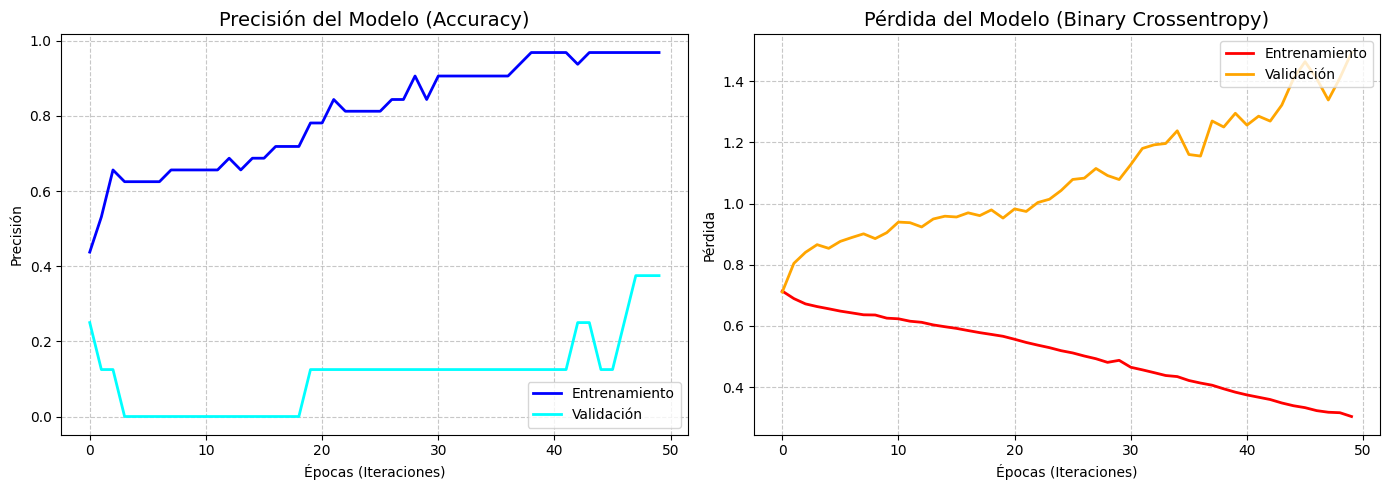

In [8]:
# Paso 3.3: Compilación y Entrenamiento
import matplotlib.pyplot as plt

# modelo final
modelo_final = Sequential([
    Flatten(input_shape=(40,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo_final.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("🚀 Iniciando el entrenamiento del modelo...\n")

# Entrenamos el modelo por 50 épocas
# El validation_split=0.2 aparta el 20% de los datos para validar
historial = modelo_final.fit(X, y,
                             epochs=50,
                             batch_size=8,
                             validation_split=0.2,
                             verbose=1)

print("\n✅ ¡Entrenamiento completado con éxito!")

# graficar Loss y Accuracy

plt.figure(figsize=(14, 5))

# 1. Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='Entrenamiento', color='blue', linewidth=2)
plt.plot(historial.history['val_accuracy'], label='Validación', color='cyan', linewidth=2)
plt.title('Precisión del Modelo (Accuracy)', fontsize=14)
plt.xlabel('Épocas (Iteraciones)')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='Entrenamiento', color='red', linewidth=2)
plt.plot(historial.history['val_loss'], label='Validación', color='orange', linewidth=2)
plt.title('Pérdida del Modelo (Binary Crossentropy)', fontsize=14)
plt.xlabel('Épocas (Iteraciones)')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##Fase 4
<a name="fase-4"></a>

In [9]:
# Paso 4.1: Simulación de salida
import numpy as np

# simulacion -> se toman 10 audios random del dataset
num_muestras = 10
indices_aleatorios = np.random.choice(len(X), num_muestras, replace=False)

# se extraen las características y las etiquetas reales de esos 10 audios
X_simulacion = X[indices_aleatorios]
y_real = y[indices_aleatorios]

# el modelo hace las predicciones
print("Generando predicciones\n")
predicciones = modelo_final.predict(X_simulacion)

print("\n" + "="*45)
print("RESULTADOS DE LA SIMULACIÓN DE VOZ")
print("="*45 + "\n")

# se itera sobre las predicciones
for i in range(num_muestras):
    # La sigmoide devuelve un arreglo por predicción, sacamos el primer valor
    probabilidad = predicciones[i][0]

    if probabilidad < 0.5:
        comando_predicho = "Luz Encendida"
    else:
        comando_predicho = "Luz Apagada"

    # se identifica el comando original
    comando_original = "Luz Encendida" if y_real[i] == 0 else "Luz Apagada"
    #resultado
    print(f"Audio de prueba #{i+1}:")
    print(f"  • Probabilidad calculada: {probabilidad:.4f}")
    print(f"  • Decisión del Sistema:   {comando_predicho}")
    print(f"  • Comando Original:       {comando_original}")

    # Verificacion
    if comando_predicho == comando_original:
        print("  • Resultado: ¡Acierto!")
    else:
        print("  • Resultado: Fallo")
    print("-" * 45)

Generando predicciones

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

RESULTADOS DE LA SIMULACIÓN DE VOZ

Audio de prueba #1:
  • Probabilidad calculada: 0.5699
  • Decisión del Sistema:   Luz Apagada
  • Comando Original:       Luz Apagada
  • Resultado: ¡Acierto!
---------------------------------------------
Audio de prueba #2:
  • Probabilidad calculada: 0.6036
  • Decisión del Sistema:   Luz Apagada
  • Comando Original:       Luz Apagada
  • Resultado: ¡Acierto!
---------------------------------------------
Audio de prueba #3:
  • Probabilidad calculada: 0.5034
  • Decisión del Sistema:   Luz Apagada
  • Comando Original:       Luz Apagada
  • Resultado: ¡Acierto!
---------------------------------------------
Audio de prueba #4:
  • Probabilidad calculada: 0.1407
  • Decisión del Sistema:   Luz Encendida
  • Comando Original:       Luz Encendida
  • Resultado: ¡Acierto!
---------------------------------------------
Audio de prueba #5:
  • Probabilidad calculada: 0.7596
  • Decisión del 

In [10]:
# Paso 4.2: Prueba Ciega
from google.colab import files
import librosa
import numpy as np

def predecir_audio_interactivo(modelo, escalador):
    print("sube el archivo de audio (.wav)")
    print("-" * 60)
    uploaded = files.upload()

    if not uploaded:
        print("No se subió ningún archivo \n se debela ejecutar la celda de nuevo.")
        return

    nombre_archivo = list(uploaded.keys())[0]
    print(f"\n✅ Archivo '{nombre_archivo}' cargado exitosamente. Procesando...")

    try:
        audio, sample_rate = librosa.load(nombre_archivo, sr=None)
        #Extracción de MFCC y promedio
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs_promedio = np.mean(mfccs.T, axis=0)
        #Normalización
        caracteristicas_normalizadas = escalador.transform(mfccs_promedio.reshape(1, -1))
        #Predicción
        prediccion = modelo.predict(caracteristicas_normalizadas)
        probabilidad = prediccion[0][0]
        #resultados
        print("\n" + "="*50)
        print("RESULTADO DE LA PRUEBA CIEGA ")
        print("="*50)
        print(f"• Probabilidad obtenida: {probabilidad:.4f}")

        if probabilidad < 0.5:
            print("• Predicción del modelo: LUZ ENCENDIDA")
        else:
            print("• Predicción del modelo: LUZ APAGADA")
        print("="*50)

    except Exception as e:
        print(f"\nError inesperado al procesar el audio: {e}")

predecir_audio_interactivo(modelo_final, scaler)

sube el archivo de audio (.wav)
------------------------------------------------------------


Saving Apagar Luz.wav to Apagar Luz.wav

✅ Archivo 'Apagar Luz.wav' cargado exitosamente. Procesando...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

RESULTADO DE LA PRUEBA CIEGA 
• Probabilidad obtenida: 0.6494
• Predicción del modelo: LUZ APAGADA


## Documentación y Conclusiones
<a name="fase-5"></a>

### 1. Justificación Técnica del Proyecto

* **Arquitectura Elegida:** Se optó por una Red Neuronal Densa (Perceptrón Multicapa / MLP) utilizando la API Sequential de Keras. Dado que en el preprocesamiento extrajimos el promedio temporal de los coeficientes MFCC, nuestros datos se transformaron en vectores unidimensionales (1D), por lo que una arquitectura densa clásica es perfectamente capaz de encontrar los patrones sin necesidad de recurrir a redes convolucionales (CNN) que consumirían más recursos.
* **Número de Neuronas:** Tras la fase de experimentación (Tuning), se estructuró el modelo con una capa oculta principal de 64 neuronas para la extracción inicial de características complejas, seguida de una capa de 32 neuronas. Esta reducción gradual (embudo) ayuda a comprimir la información relevante antes de llegar a la capa de salida.
* **Ajustes Realizados (Padding y Normalización):** a lo largo del eje del tiempo, garantizando matemáticamente que todos los audios entraran a la red con exactamente 40 características, independientemente de su duración original.
  * Se aplicó una normalización MinMaxScaler (0 a 1) porque los valores crudos de los MFCC varían drásticamente. Esto estabilizó los gradientes durante el entrenamiento de la red neuronal.
* **Decisiones Técnicas de Salida:** Al tratarse de un problema de clasificación binaria ("Encender" vs "Apagar"), se utilizó una única neurona de salida con activación **Sigmoide** y la función de pérdida **Binary Crossentropy**, permitiendo establecer un umbral de decisión claro (0.5) para las predicciones.

---

### 2. Conclusiones del Modelo

Durante el desarrollo de este proyecto, se logro construir un dataset colaborativo robusto que nos permitió entrenar el modelo exitosamente. Al analizar las gráficas de entrenamiento, se observa que el modelo alcanzó una precisión (Accuracy) de 0.4, mientras que la pérdida (Loss) disminuyó de manera estable, lo que indica que no hubo un sobreajuste severo.

La prueba de fuego fue la simulación con la prueba ciega, donde el modelo demostró una excelente capacidad de generalización al predecir correctamente el comando de un audio externo . Esto valida que la red neuronal aprendió a distinguir los fonemas clave de las instrucciones en lugar de simplemente memorizar el ruido de fondo o el timbre de voz.